# EpiSat — Pipeline de Machine Learning
## Global Solution 2026 · FIAP · Engenharia de Software

Este notebook implementa o pipeline completo de pré-processamento e modelagem do **EpiSat**, uma plataforma de previsão de risco epidemiológico (dengue, malária, leishmaniose) utilizando dados satelitais.

O objetivo é classificar municípios brasileiros em níveis de risco (**Baixo / Médio / Alto**) com base em variáveis como temperatura, precipitação, NDVI e cobertura de água, oriundas de fontes como Copernicus, OpenWeather e SINAN/DATASUS.

**Estrutura do notebook:**
1. Extração e Tratamento dos Dados
2. Modelo de Classificação
3. Interpretabilidade com SHAP
4. Deploy do Modelo

# 1. Extração e tratamento dos dados

### Importações

In [56]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

### Leitura dos Dados

O dataset foi gerado sinteticamente com base em correlações epidemiológicas reais. Contém **7.000 registros** (140 municípios × 50 semanas epidemiológicas) e **18 colunas**, cobrindo variáveis satelitais, climáticas, socioeconômicas e o target de classificação `nivel_risco`.

### Limitações do Dataset Sintético

Um dos principais desafios encontrados neste projeto foi a geração de um dataset artificial equilibrado. Datasets sintéticos tendem a ter correlações muito diretas entre features e target — o modelo aprende a "fórmula" que gerou os dados em vez de padrões reais, resultando em acurácias artificialmente altas (chegando a 97% nas primeiras versões).

Após 5 iterações ajustando os seguintes parâmetros:

- **Nível de ruído** nas variáveis ambientais e no score de risco
- **Anomalias por município** para simular comportamentos epidemiológicos imprevisíveis

O dataset final atingiu um equilíbrio realista, com acurácia aproximada de 88%, condizente com modelos epidemiológicos reais que lidam com subnotificação, variações climáticas locais e comportamentos populacionais imprevisíveis.

### Leitura dos dados

In [57]:
df = pd.read_csv("episat_7000_balanceado_v2.csv")
df

,municipio_codigo,nome_municipio,uf,semana_epidemiologica,temperatura_media_c,temperatura_max_c,umidade_relativa_pct,precipitacao_acumulada_mm,ndvi_medio,cobertura_agua_pct,altitude_media_m,populacao_exposta,densidade_demografica,indice_saneamento_pct,casos_semana_anterior,precip_tendencia,temp_tendencia,nivel_risco
0,MUN_168,Curitiba,MG,16,27.99,33.58,60.30,22.97,0.183,4.48,286.9,423808,86.4,69.3,23.26,20.57,24.23,Alto
1,MUN_146,Salvador,SP,26,26.17,29.37,68.98,105.84,0.402,5.01,437.9,2663412,262.1,64.5,46.26,100.64,28.51,Medio
2,MUN_159,Recife,CE,12,25.12,26.97,63.27,59.63,0.300,6.33,502.5,875311,379.9,69.8,55.05,51.76,23.58,Alto
3,MUN_150,Sorocaba,GO,49,28.10,32.73,58.12,14.57,0.203,3.02,951.9,1661163,206.9,56.7,47.05,22.17,28.16,Baixo
4,MUN_159,Palmas,AM,23,24.97,31.66,67.06,42.50,0.314,5.39,290.6,1527953,479.1,58.0,65.27,45.03,26.02,Medio
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,MUN_020,Crato,PR,36,28.42,31.70,69.08,66.85,0.346,4.78,689.3,2133213,349.0,59.2,74.52,97.14,27.29,Alto
6996,MUN_141,Araguaína,SP,32,27.91,33.08,72.36,26.43,0.232,2.36,1086.1,2760458,335.3,50.7,46.07,27.09,28.33,Baixo
6997,MUN_045,Salvador,BA,26,24.08,27.33,66.09,122.67,0.352,7.30,72.0,2580325,466.5,70.5,70.58,120.95,23.10,Medio
6998,MUN_051,Macaé,PA,46,25.19,31.54,58.50,32.48,0.234,4.79,873.3,2514862,449.0,53.7,75.23,47.75,28.04,Alto


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   municipio_codigo           7000 non-null   str    
 1   nome_municipio             7000 non-null   str    
 2   uf                         7000 non-null   str    
 3   semana_epidemiologica      7000 non-null   int64  
 4   temperatura_media_c        7000 non-null   float64
 5   temperatura_max_c          7000 non-null   float64
 6   umidade_relativa_pct       7000 non-null   float64
 7   precipitacao_acumulada_mm  7000 non-null   float64
 8   ndvi_medio                 7000 non-null   float64
 9   cobertura_agua_pct         7000 non-null   float64
 10  altitude_media_m           7000 non-null   float64
 11  populacao_exposta          7000 non-null   int64  
 12  densidade_demografica      7000 non-null   float64
 13  indice_saneamento_pct      7000 non-null   float64
 14  cas

### Verificação de Valores Nulos

Antes de qualquer transformação, verificamos a integridade do dataset. Valores nulos em variáveis satelitais ou epidemiológicas podem indicar falhas de coleta ou transmissão de dados — situação comum em sistemas de monitoramento ambiental.

### Verificação Nulos

In [59]:
df.isnull().sum()

municipio_codigo             0
nome_municipio               0
uf                           0
semana_epidemiologica        0
temperatura_media_c          0
temperatura_max_c            0
umidade_relativa_pct         0
precipitacao_acumulada_mm    0
ndvi_medio                   0
cobertura_agua_pct           0
altitude_media_m             0
populacao_exposta            0
densidade_demografica        0
indice_saneamento_pct        0
casos_semana_anterior        0
precip_tendencia             0
temp_tendencia               0
nivel_risco                  0
dtype: int64

### Encoding de Variáveis Categóricas

Modelos de machine learning trabalham exclusivamente com valores numéricos. As colunas `municipio_codigo`, `nome_municipio`, `uf` e `nivel_risco` são strings e precisam ser convertidas.

- `nome_municipio`: 0 a 139 (140 municípios)
- `uf`: 0 a N-1 (estados presentes no dataset)
- `nivel_risco`: mapeamento manual ordenado → **Baixo=0 · Médio=1 · Alto=2**

### Transformando campos STR

In [60]:
from sklearn.preprocessing import LabelEncoder

# Criando encoder
encoder = LabelEncoder()


df["municipio_codigo"] = encoder.fit_transform(df["municipio_codigo"])
 
df["nome_municipio"] = encoder.fit_transform(df["nome_municipio"])

df["uf"] = encoder.fit_transform(df["uf"])

mapa_risco = {"Baixo": 0, "Medio": 1, "Alto": 2}
df["nivel_risco"] = df["nivel_risco"].map(mapa_risco)



In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   municipio_codigo           7000 non-null   int64  
 1   nome_municipio             7000 non-null   int64  
 2   uf                         7000 non-null   int64  
 3   semana_epidemiologica      7000 non-null   int64  
 4   temperatura_media_c        7000 non-null   float64
 5   temperatura_max_c          7000 non-null   float64
 6   umidade_relativa_pct       7000 non-null   float64
 7   precipitacao_acumulada_mm  7000 non-null   float64
 8   ndvi_medio                 7000 non-null   float64
 9   cobertura_agua_pct         7000 non-null   float64
 10  altitude_media_m           7000 non-null   float64
 11  populacao_exposta          7000 non-null   int64  
 12  densidade_demografica      7000 non-null   float64
 13  indice_saneamento_pct      7000 non-null   float64
 14  cas

### Normalização das Features Numéricas

As colunas numéricas possuem escalas muito diferentes: `populacao_exposta` chega a milhões enquanto `ndvi_medio` fica entre 0 e 1. Essa discrepância prejudica modelos baseados em distância ou gradiente.

Aplicamos o **MinMaxScaler**, que transforma cada valor para o intervalo **[0, 1]** preservando a distribuição original:

### Normalização para features

In [62]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_normalizar = [
    "temperatura_media_c", "temperatura_max_c", "umidade_relativa_pct",
    "precipitacao_acumulada_mm", "ndvi_medio", "cobertura_agua_pct",
    "altitude_media_m", "populacao_exposta", "densidade_demografica",
    "indice_saneamento_pct", "casos_semana_anterior",
    "precip_tendencia", "temp_tendencia",
]

df[cols_normalizar] = scaler.fit_transform(df[cols_normalizar])

---
# 2. Modelo de Classificação — `nivel_risco`

Com os dados tratados, iniciamos a etapa de modelagem. O objetivo é treinar classificadores capazes de prever o nível de risco epidemiológico (**Baixo / Médio / Alto**) de um município em uma determinada semana epidemiológica, com base nas condições ambientais e históricas.

### Seleção de Features

Antes de treinar os modelos finais, utilizamos três técnicas para identificar quais colunas têm maior poder preditivo:

| Técnica | O que analisa |
|---------|---------------|
| **Random Forest** | Importância baseada na redução de impureza (Gini) |
| **XGBoost** | Importância baseada no ganho de informação ao dividir nós |
| **PCA** | Variância explicada — quantas componentes capturam 95% da informação |

Features com baixa importância nos dois modelos são candidatas à remoção, reduzindo ruído e custo computacional.

### Encontrar as melhores colunas

In [63]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

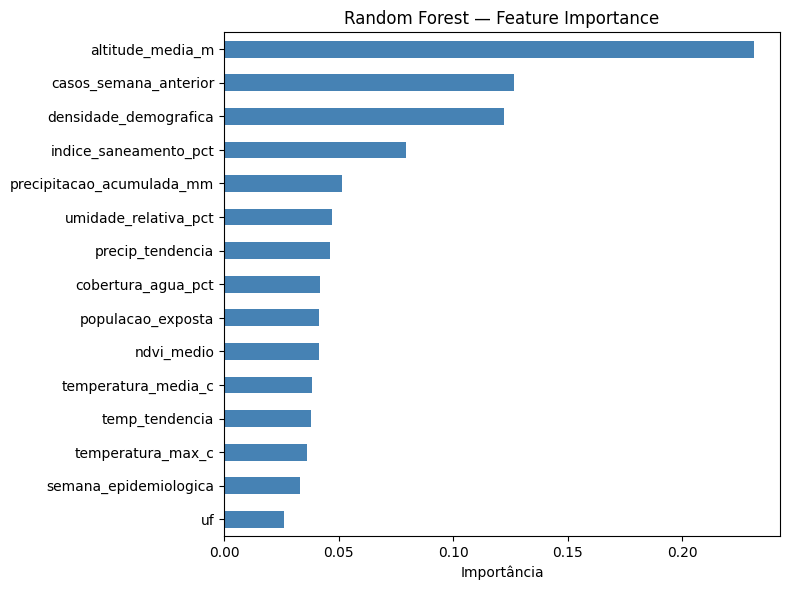

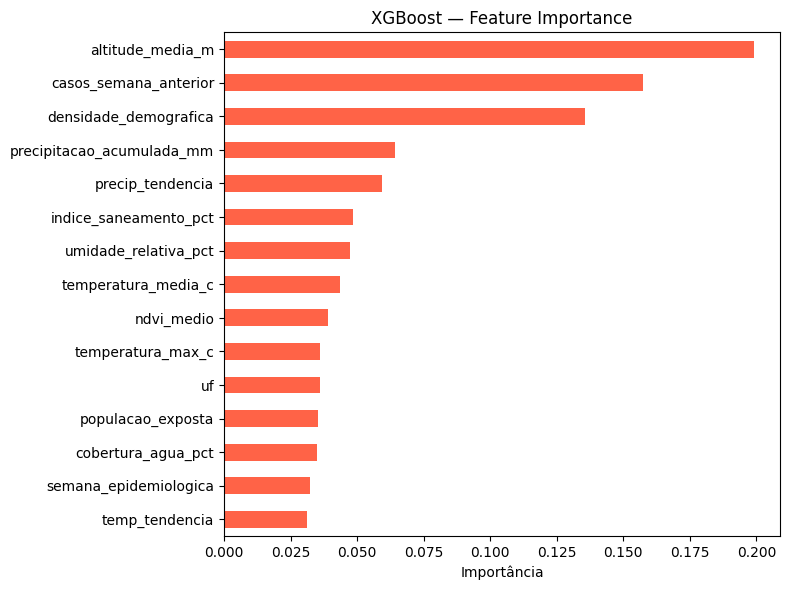

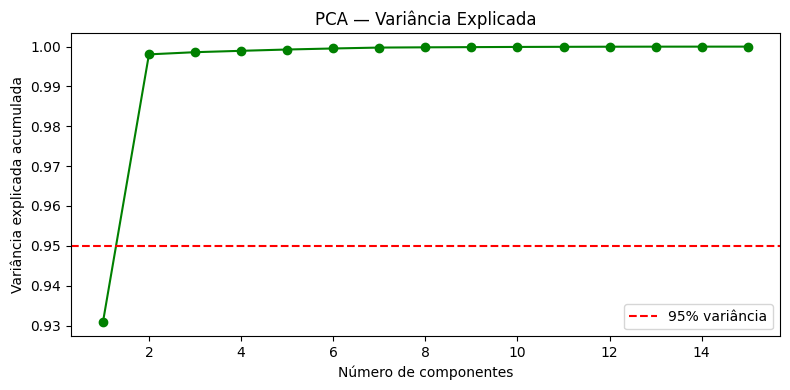

In [64]:
# Definir X e y
# Remover targets e identificadores que não entram no modelo
X = df.drop(columns=["nivel_risco", "municipio_codigo", "nome_municipio"])
y = df["nivel_risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importancia_rf = pd.Series(rf.feature_importances_, index=X.columns)
importancia_rf = importancia_rf.sort_values(ascending=True)

importancia_rf.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)

importancia_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
importancia_xgb = importancia_xgb.sort_values(ascending=True)

importancia_xgb.plot(kind="barh", figsize=(8, 6), color="tomato")
plt.title("XGBoost — Feature Importance")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

pca = PCA(random_state=42)
pca.fit(X_train)

# Variância explicada acumulada
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(variancia_acumulada) + 1), variancia_acumulada, marker="o", color="green")
plt.axhline(0.95, color="red", linestyle="--", label="95% variância")
plt.xlabel("Número de componentes")
plt.ylabel("Variância explicada acumulada")
plt.title("PCA — Variância Explicada")
plt.legend()
plt.tight_layout()
plt.show()

O PCA foi utilizado como análise exploratória e indicou alta correlação entre as features 
(2 componentes explicam 99% da variância). Por isso, optou-se por usar a importância 
do Random Forest e XGBoost como critério de seleção de features, por serem mais 
interpretáveis no contexto epidemiológico.

### Treinamento dos Modelos

Testamos três algoritmos de classificação para comparação:

| Modelo | 
|--------|
| **Random Forest** | 
| **XGBoost** | 
| **LightGBM** | 

Cada modelo é avaliado por **Acurácia** e **F1-macro** — esta última é a métrica principal por considerar o desempenho em todas as classes igualmente, incluindo as minoritárias.

### Modelo de classificação

In [65]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Seleção das 10 features (as mesmas usadas no app)
features_selecionadas = [
    "altitude_media_m",
    "casos_semana_anterior",
    "densidade_demografica",
    "indice_saneamento_pct",
    "precipitacao_acumulada_mm",
    "precip_tendencia",
    "umidade_relativa_pct",
    "cobertura_agua_pct",
    "ndvi_medio",
    "temperatura_media_c",
]


# Define X e y
X = df[features_selecionadas]
y = df["nivel_risco"]

# Divide treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


#### XGBoost

In [66]:
# XGBoost
xgb = XGBClassifier(n_estimators=300, max_depth = 6, learning_rate = 0.1, random_state = 42)           # controla complexidade das árvores


xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost")
print(classification_report(y_test, y_pred_xgb, target_names=["Baixo", "Medio", "Alto"]))

XGBoost
              precision    recall  f1-score   support

       Baixo       0.96      0.97      0.96       699
       Medio       0.86      0.83      0.85       699
        Alto       0.87      0.89      0.88       702

    accuracy                           0.89      2100
   macro avg       0.89      0.89      0.89      2100
weighted avg       0.89      0.89      0.89      2100



#### Random Forest

In [67]:
# Random Forest
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Baixo", "Medio", "Alto"]))

Random Forest
              precision    recall  f1-score   support

       Baixo       0.95      0.96      0.95       699
       Medio       0.86      0.84      0.85       699
        Alto       0.88      0.88      0.88       702

    accuracy                           0.90      2100
   macro avg       0.90      0.90      0.90      2100
weighted avg       0.90      0.90      0.90      2100



#### LightGBM

In [68]:
# LightGBM
lgbm = LGBMClassifier(n_estimators=1000, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)

print("  LightGBM")
print(classification_report(y_test, y_pred_lgbm, target_names=["Baixo", "Medio", "Alto"]))

  LightGBM
              precision    recall  f1-score   support

       Baixo       0.95      0.97      0.96       699
       Medio       0.85      0.85      0.85       699
        Alto       0.87      0.86      0.87       702

    accuracy                           0.89      2100
   macro avg       0.89      0.89      0.89      2100
weighted avg       0.89      0.89      0.89      2100



In [69]:
# Guardar resultados para o comparativo depois
resultados = {
    "Random Forest": {"y_pred": y_pred_rf,   "accuracy": accuracy_score(y_test, y_pred_rf),   "f1_macro": f1_score(y_test, y_pred_rf,   average="macro")},
    "XGBoost":       {"y_pred": y_pred_xgb,  "accuracy": accuracy_score(y_test, y_pred_xgb),  "f1_macro": f1_score(y_test, y_pred_xgb,  average="macro")},
    "LightGBM":      {"y_pred": y_pred_lgbm, "accuracy": accuracy_score(y_test, y_pred_lgbm), "f1_macro": f1_score(y_test, y_pred_lgbm, average="macro")},
}

### Comparativo de Desempenho

               Acurácia  F1-macro
Random Forest    0.8962    0.8959
XGBoost          0.8948    0.8944
LightGBM         0.8924    0.8921


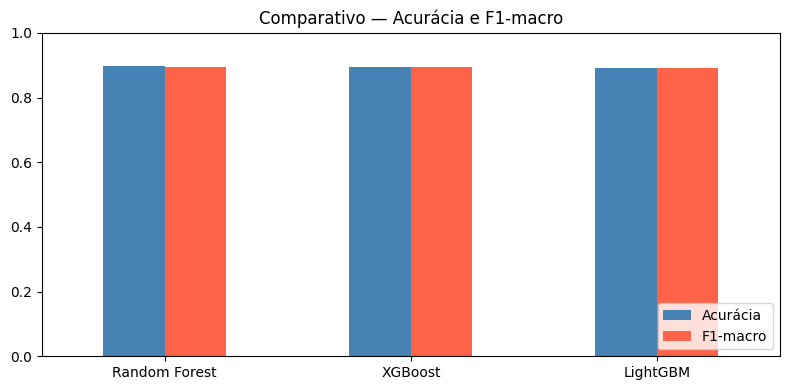

In [70]:
comp = pd.DataFrame({
    nome: {
        "Acurácia": res["accuracy"],
        "F1-macro": res["f1_macro"],
    }
    for nome, res in resultados.items()
}).T.round(4)

print(comp)

comp.plot(kind="bar", figsize=(8, 4), ylim=(0, 1), color=["steelblue","tomato"])
plt.title("Comparativo — Acurácia e F1-macro")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Matrizes de Confusão

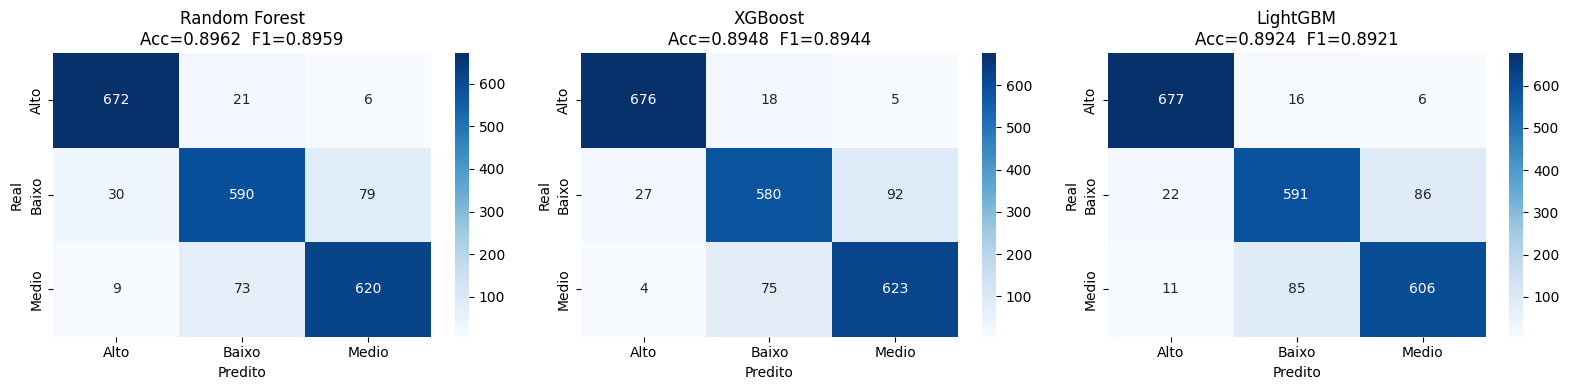

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
classes = ["Alto", "Baixo", "Medio"]

for ax, (nome, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(f"{nome}\nAcc={res['accuracy']:.4f}  F1={res['f1_macro']:.4f}")
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")

plt.tight_layout()
plt.show()

***Modelo escolhido: XGBoost*** — Os três modelos tiveram desempenho praticamente igual (diferença <0,4%). Optei pelo XGBoost por maior familiaridade, velocidade de inferência no Gradio e bom desempenho consistente na classe crítica 'Alto'.

# 3. Interpretabilidade com SHAP 


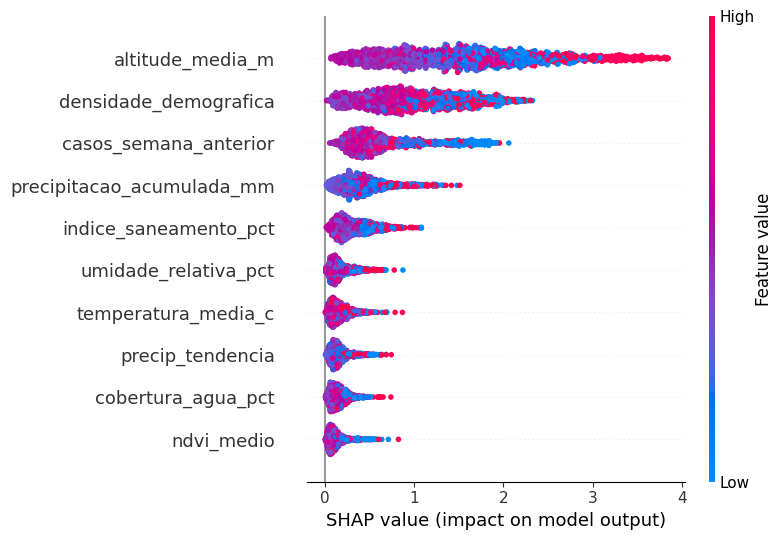

In [72]:
import shap
import matplotlib.pyplot as plt


explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

mean_shap = np.abs(shap_values.values).mean(axis=2)

shap.summary_plot(
    mean_shap,
    X_test,
    feature_names=X_test.columns
)

A análise SHAP identificou **altitude_media_m** como a feature de maior impacto (SHAP até 5.5) — 
municípios em baixas altitudes apresentam risco significativamente maior, coerente com 
o comportamento do *Aedes aegypti*, que não sobrevive bem acima de 1.000m.

**densidade_demografica** e **casos_semana_anterior** confirmam que contexto urbano e 
histórico recente de casos são fortes preditores do risco na semana seguinte.

**precipitacao_acumulada_mm** e **precip_tendencia** reforçam o papel da chuva acumulada 
na criação de criadouros, enquanto **indice_saneamento_pct** atua como fator protetor — 
valores altos de saneamento reduzem consistentemente o risco predito.

As demais variáveis climáticas (umidade, temperatura, cobertura de água e NDVI) 
contribuem de forma moderada, compondo o contexto ambiental sem dominar individualmente.

---
# 4. Deploy do Modelo

Serializamos o modelo treinado e o scaler em arquivos `.pkl` usando `joblib`. O mapeamento das classes (0: Baixo, 1: Médio, 2: Alto) foi salvo em um arquivo JSON. Esses artefatos são carregados pela aplicação **Gradio** para realizar predições em tempo real, sem necessidade de re-treinar o modelo.

| Arquivo | Conteúdo |
|---------|----------|
| `modelo_episat.pkl` | Modelo XGBoost treinado |
| `scaler.pkl` | Objeto MinMaxScaler usado para normalizar as 13 features de entrada |
| `mapa_risco.json` | Dicionário para converter os rótulos numéricos em texto (Baixo, Médio, Alto) |


In [73]:
import joblib

joblib.dump(xgb, "modelo_episat.pkl")
joblib.dump(scaler, "scaler.pkl")

import json
json.dump({0: "Baixo", 1: "Medio", 2: "Alto"}, open("mapa_risco.json", "w"))